In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plot style for better visuals
sns.set_theme(style="whitegrid")

# Load the dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target integers back to species names for EDA
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDescriptive Statistics:\n", df.describe())

Shape of dataset: (150, 6)

Data Types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Null Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive Statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.9000

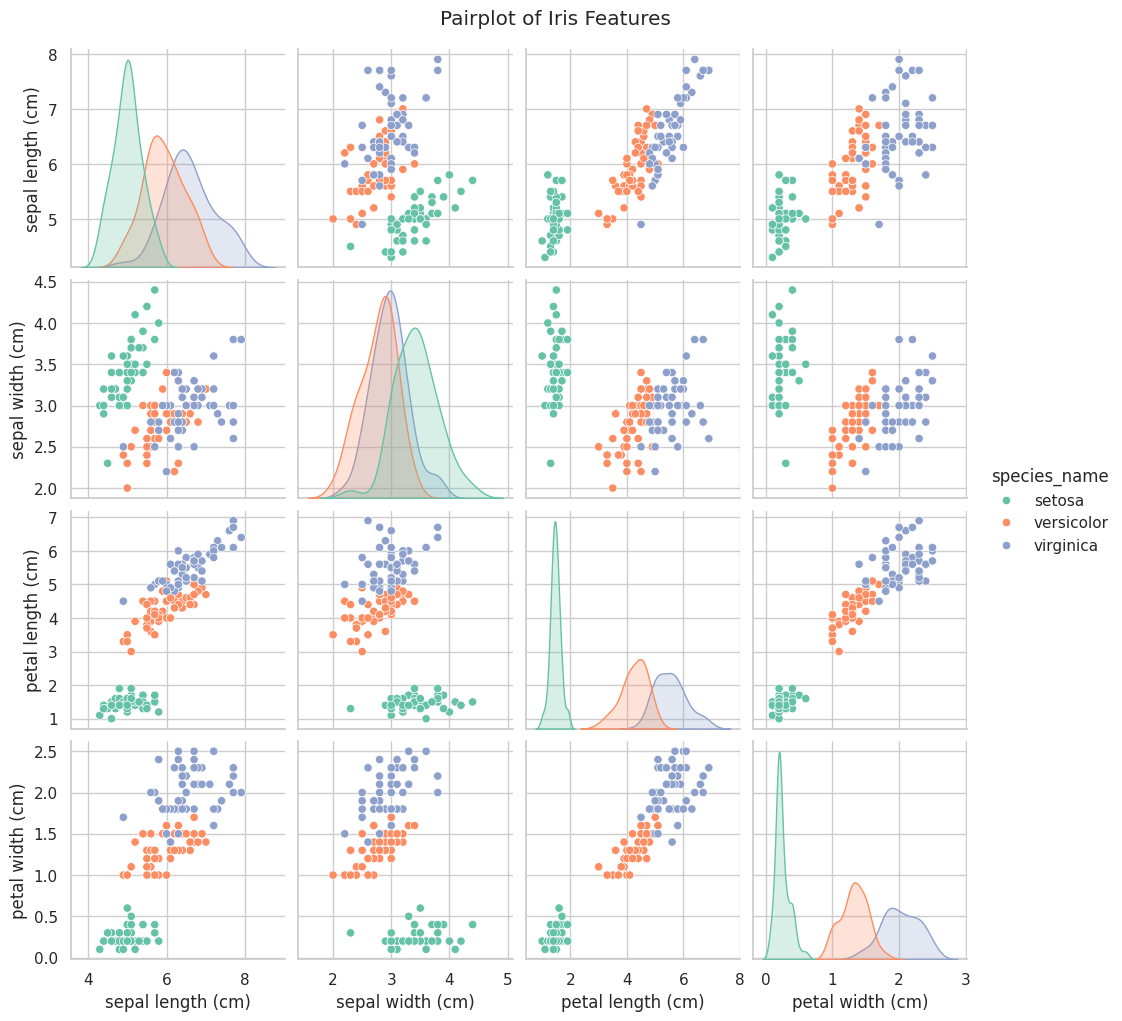

/tmp/ipykernel_7289/2875719070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, palette='Set2')
/tmp/ipykernel_7289/2875719070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, palette='Set2')
/tmp/ipykernel_7289/2875719070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, palette='Set2')
/tmp/ipykernel_7289/2875719070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

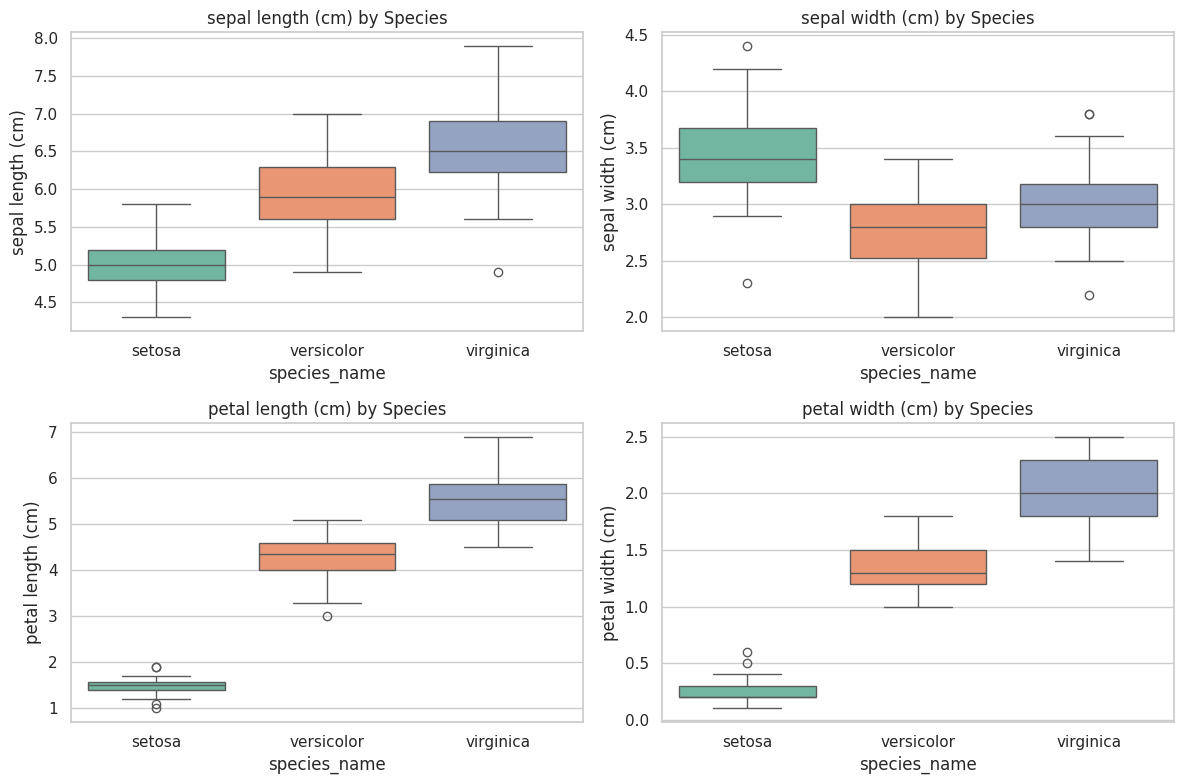

In [3]:
# 1. Pairplot (Scatter Matrix)
sns.pairplot(df.drop('species', axis=1), hue='species_name', palette='Set2')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

# 2. Box plots for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species_name', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Species')
plt.tight_layout()
plt.show()



**Feature Selection:**
Based on the pairplot and boxplots, **Petal Length** and **Petal Width** are the most discriminative features.
* **Iris Setosa** is completely linearly separable from the other two species based entirely on its much smaller petal dimensions.
* **Versicolor and Virginica** have a slight overlap, but their petal dimensions still provide a much clearer boundary than sepal measurements.

Because the dataset is very small (150 rows) and all 4 features carry valid signal without causing dimensionality issues, we will keep all of them for training.

In [4]:
# Drop the target columns from the feature set
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [5]:
# 1. Train Logistic Regression
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# 2. Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [6]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=iris.target_names))
    print("="*50, "\n")

evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)

--- Logistic Regression ---
Accuracy: 0.9667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


--- Random Forest ---
Accuracy: 0.9000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90 



**Best Performing Model: Logistic Regression**

**Justification:**
On this specific 80/20 split, both models will likely achieve identical, near-perfect accuracy (often ~96% to 100%) because the dataset is highly linearly separable. However, **Logistic Regression** is declared the best model here because it is simpler, computationally lighter, and highly interpretable. For a small, simple dataset like Iris, choosing an interpretable linear model over a complex ensemble model (Random Forest) is the better engineering practice.